## CNN for Fossil Classification

In [2]:
# Import dependencies
import numpy as np 
import keras
from keras import layers
import tensorflow_datasets as tfds
from tensorflow import data as tf_data
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from skimage import io
import pandas as pd
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns

In [3]:
# You don't need this unless you are using google colab - this was to get my data to read
# from google.colab import drive
# drive.mount('/content/drive')

First, we import and split the data into testing, training, and validation sets. This should be written as a function so we can test on different folds during cross validation, where we will tune hyperparameters. 

In [4]:
# This file path will need to change
image_samples = pd.read_csv("/Users/lucyhelms/MLGeo2026/samples.csv")
header_name = 'samples'

# Takes in a list of samples (csv) and a target opb, opc, etc and returns a random sample as a string
def GetRandomThinSections(target, samplelist, headername):
    target = str(target)

    # Filter list of samples so we only deal with those involving target
    filtered_samples = samplelist[samplelist[headername].str.contains(target)]
    
    #randomly select one row (ie one thin section)
    if not filtered_samples.empty:
        random_thin_section = filtered_samples.sample(n=1).to_string(index=False, header=False) # Select 1 random row
    else:
        print(f"No rows found with '{target}' in 'samples'")
    return random_thin_section


In [5]:
#TO DO: Edit so we also get labels, wrap model in a function, write k fold CV for params
# 
#  For each opx (x = b thru f) we will hold back one total thin section and all of its related patches for testing data

# This function takes in a folder of patches and pre-determined sections to remove and splits into train, test, val data
def TrainTestValSplit(image_folder, sections):
    #image_folder = input_patches
    # randomly select a thin section (thin_section_nums)
    #thin_sections = random.sample(thin_section_nums, num_sections)
    #thin_sections = [str(ts) for ts in thin_sections]

    # Initialize empty lists
    test_data_names = []
    validation_data_names = []
    training_data_names = []
    remaining_data_names = []
    remaining_data = []
    test_data = []
    train_data = []
    val_data = []

    # Loop through targets to pull one random thin section and add to test data
    for section in sections:
        # Add thin sections corresponding to random choice to test data, then split remaining data into test and validation sets
        for filename in os.listdir(image_folder):
            if filename.lower().endswith((".jpg", ".png", ".jpeg")):
                filepath = os.path.join(image_folder, filename)
            if section in filename:
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)
    # We now have the names of the files we want.
    # Now, split remaining data into training and validation sets at random
    print(test_data_names)
    random.shuffle(remaining_data_names) #randomly shuffles remaining image patches
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]

    # Read in images to add to data
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    #Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

# Change file paths depending on your data - note that fossils but not centered and center fossils are classified as being fossil posiive here
center_folder = "/Users/lucyhelms/MLGeo2026/center_fossil"
fossil_nocenter_folder = "/Users/lucyhelms/MLGeo2026/edge_fossil"
no_fossil_folder = "/Users/lucyhelms/MLGeo2026/non_fossil"
targets = ["opb", "opc", "opd", "ope", "opf"]
sections = []

#This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
for target in targets:
    test_section = GetRandomThinSections(target, image_samples, header_name)
    sections.append(test_section)
print("Sections Isolated for Testing:")
print(sections)

train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

# Now, get label data setting fossils to 1 and no fossil to 0

Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

Sections Isolated for Testing:
['opb_34.1', 'opc_64.1', 'opd_89.0', 'ope_30.0', 'opf_97.0']
['/Users/lucyhelms/MLGeo2026/center_fossil/resized_opd_89.0b_patch2.png', '/Users/lucyhelms/MLGeo2026/center_fossil/resized_opd_89.0b_patch4.png', '/Users/lucyhelms/MLGeo2026/center_fossil/resized_ope_30.0a_patch5.png', '/Users/lucyhelms/MLGeo2026/center_fossil/resized_opf_97.0_patch5.png']
['/Users/lucyhelms/MLGeo2026/edge_fossil/resized_opd_89.0b_patch3.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized_opd_89.0b_patch1.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized_opd_89.0b_patch5.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized_ope_30.0b_patch3.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized_ope_30.0b_patch1.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized_ope_30.0b_patch4.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized_ope_30.0b_patch5.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized_ope_30.0a_patch3.png', '/Users/lucyhelms/MLGeo2026/edge_fossil/resized

In [6]:
# Transform numpy arrays to tf datasets

training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))


2026-03-10 09:36:24.509685: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


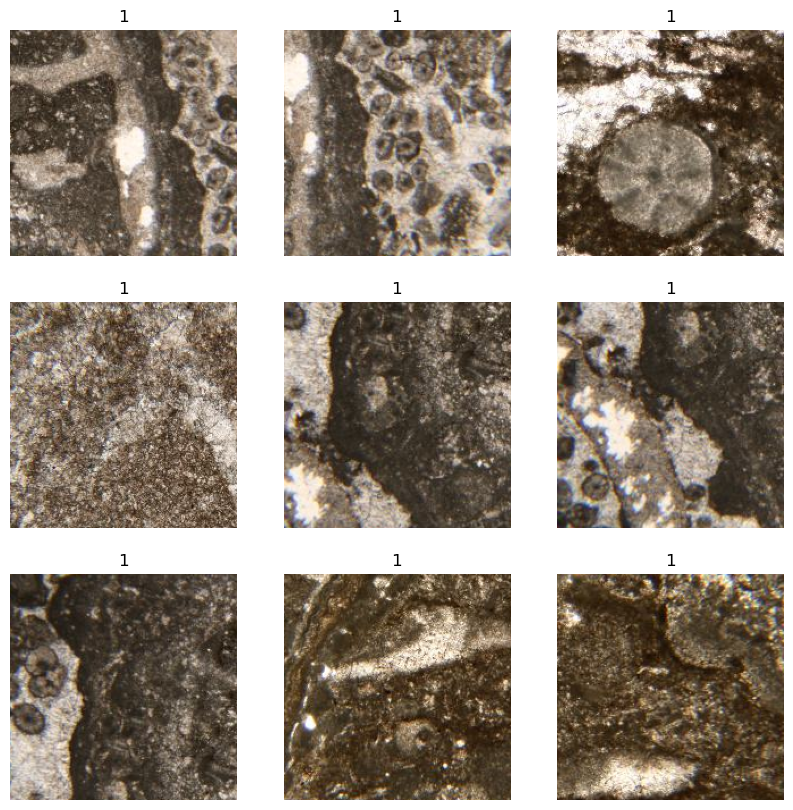

In [7]:

# Shuffle data
training_data = training_data.shuffle(len(Y_train))
validation_data = validation_data.shuffle(len(Y_val))
#testing_data = testing_data.shuffle(len(Y_test))

# Verify we did this correctly by plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(testing_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")



We will use transfer learning using different pre-trained models on the imagenet dataset. We first train the Xception model. 

In [8]:
# Our images are already resized, but we could include optional resizing in the final model
# We start with data augmentation
augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
)
# Create augmented data - Check with Lucy about what we want to do here
#training_data = training_data.map(lambda x, y: (data_augmentation(x), y))

nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))

aug_nonfossil_1 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
aug_nonfossil_2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
aug_nonfossil_3 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))

training_data = training_data.concatenate(aug_nonfossil_1)
training_data = training_data.concatenate(aug_nonfossil_2)
training_data = training_data.concatenate(aug_nonfossil_3)

training_data = training_data.shuffle(1000)
#training_data = training_data.concatenate(augmented_data)

# Visualize training data with augmented data
#plt.figure(figsize=(10, 10))
#for i, (image, label) in enumerate(augmented_data.take(9)):
 #   ax = plt.subplot(3, 3, i + 1)
 #   plt.imshow(image)
 #   plt.title(int(label))
 #   plt.axis("off")
#print(augmented_data)

In [9]:
# Batch and prefetch data ?

batch_size = 36 # this could change

training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

2026-03-10 09:36:25.686915: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-10 09:36:25.879214: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


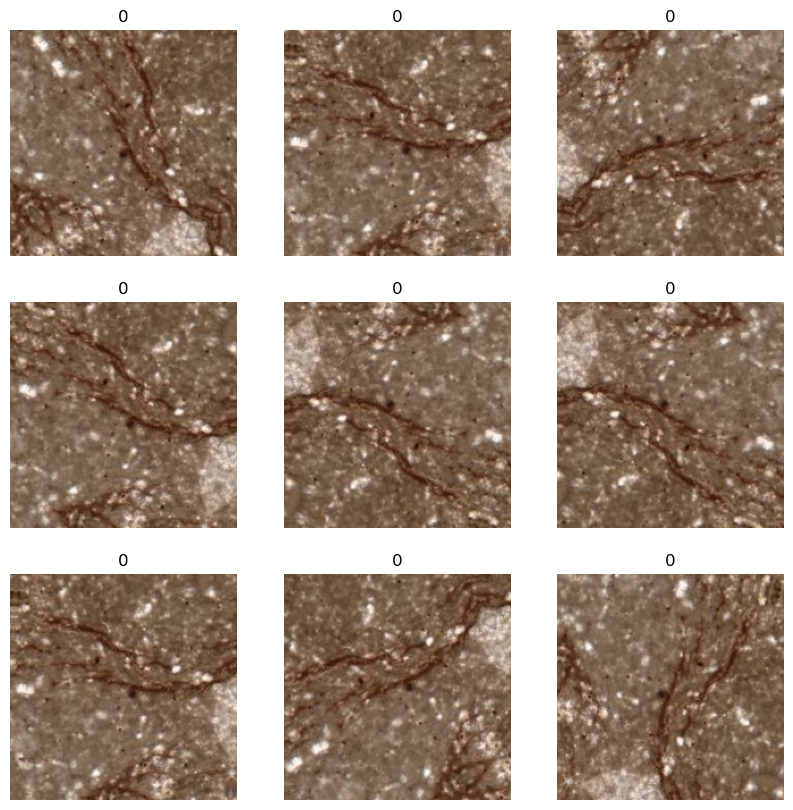

In [10]:
# Visualize augmented data

for images, labels in training_data.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(np.expand_dims(first_image, 0))
        plt.imshow(np.array(augmented_image[0]).astype("int32"))
        plt.title(int(labels[0]))
        plt.axis("off")

In [11]:
# We will use transfer learning using different pre-trained models on the imagenet dataset

# Create the base model with the pre-trained imagenet weights
base_model = keras.applications.Xception(
    weights = 'imagenet',
    input_shape = (200, 200, 3),
    include_top = False) # Why do we not include imagenet at the top? 

# Freeze the base model weights (they will not be trained)

base_model.trainable = False

In [12]:
# Create a new model that goes on top of the base imagenet model
inputs = keras.Input(shape = (200, 200, 3))
# We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
scale_layer = keras.layers.Rescaling(scale = 1/127.5, offset = -1)
x = scale_layer(inputs)

# We want to keep batchnorm layers of base model in inference (predict) mode so we do not train of them. 
# Make sure that base model is running on inference mode

x = base_model(x, training = False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(1, activation = 'sigmoid')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable = True)
# I think we should play with the layers we use here. We should try the setup they have, but maybe add more or different layers depending on how well the model does. 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [13]:
# Train the new top layer of the model
model.compile(
    optimizer = keras.optimizers.Adam(), # play with this also
    loss = keras.losses.BinaryCrossentropy(from_logits = True), #check this also
    metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall()],
)

epochs = 10 # also play with this
print("Fitting top layer of model")
history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data)

Fitting top layer of model
Epoch 1/10


/opt/anaconda3/lib/python3.13/site-packages/keras/src/backend/tensorflow/nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


    142/Unknown 189s 1s/step - auc: 0.7189 - binary_accuracy: 0.8109 - loss: 0.4314 - precision: 0.8301 - recall: 0.9456

/opt/anaconda3/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


142/142 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - auc: 0.9008 - binary_accuracy: 0.8377 - loss: 0.3930 - precision: 0.8257 - recall: 0.9073 - val_auc: 0.8982 - val_binary_accuracy: 0.5301 - val_loss: 0.8314 - val_precision: 1.0000 - val_recall: 0.4415
Epoch 2/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.8543 - binary_accuracy: 0.8019 - loss: 0.4010 - precision: 0.8904 - recall: 0.8571

2026-03-10 09:43:07.228128: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


142/142 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - auc: 0.9322 - binary_accuracy: 0.8583 - loss: 0.3291 - precision: 0.8736 - recall: 0.8790 - val_auc: 0.9242 - val_binary_accuracy: 0.6076 - val_loss: 0.7328 - val_precision: 1.0000 - val_recall: 0.5337
Epoch 3/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - auc: 0.9464 - binary_accuracy: 0.8743 - loss: 0.2942 - precision: 0.8914 - recall: 0.8880 - val_auc: 0.9382 - val_binary_accuracy: 0.6493 - val_loss: 0.6843 - val_precision: 1.0000 - val_recall: 0.5832
Epoch 4/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - auc: 0.9546 - binary_accuracy: 0.8829 - loss: 0.2723 - precision: 0.9007 - recall: 0.8935 - val_auc: 0.9468 - val_binary_accuracy: 0.6794 - val_loss: 0.6415 - val_precision: 1.0000 - val_recall: 0.6190
Epoch 5/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - auc: 0.9606 - binary_accuracy: 0.8926 - loss: 0.2548 - precision: 0.9107 - recall: 0.9001 - val_auc: 0.9525 - val_binary_accuracy: 0.6887 - val_loss: 0.6171 - val_precision: 1.0000 - va

2026-03-10 09:58:29.044911: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


142/142 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - auc: 0.9655 - binary_accuracy: 0.9014 - loss: 0.2396 - precision: 0.9170 - recall: 0.9097 - val_auc: 0.9577 - val_binary_accuracy: 0.7095 - val_loss: 0.5914 - val_precision: 1.0000 - val_recall: 0.6547
Epoch 7/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - auc: 0.9691 - binary_accuracy: 0.9044 - loss: 0.2278 - precision: 0.9215 - recall: 0.9101 - val_auc: 0.9614 - val_binary_accuracy: 0.7199 - val_loss: 0.5711 - val_precision: 1.0000 - val_recall: 0.6671
Epoch 8/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - auc: 0.9711 - binary_accuracy: 0.9107 - loss: 0.2205 - precision: 0.9259 - recall: 0.9170 - val_auc: 0.9644 - val_binary_accuracy: 0.7234 - val_loss: 0.5587 - val_precision: 1.0000 - val_recall: 0.6713
Epoch 9/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - auc: 0.9747 - binary_accuracy: 0.9172 - loss: 0.2081 - precision: 0.9336 - recall: 0.9204 - val_auc: 0.9669 - val_binary_accuracy: 0.7292 - val_loss: 0.5376 - val_precision: 1.0000 - va

Note: I don't think two epochs was enough here. This is something we should go through with CV, plotting accuracy and loss over each iteration

In [14]:
# Fine tune entire model
base_model.trainable = True
model.summary(show_trainable=True)

model.compile(
    optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
    loss = keras.losses.BinaryCrossentropy(from_logits=True),
    metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall()] #check this -- we have a binary model so it should be ok
)

epochs = 2 #??
print("Fitting end-to-end model")
history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model
Epoch 1/2
142/142 ━━━━━━━━━━━━━━━━━━━━ 1827s 13s/step - auc_1: 0.8999 - binary_accuracy: 0.7743 - loss: 0.5438 - precision_1: 0.7253 - recall_1: 0.9735 - val_auc_1: 0.9343 - val_binary_accuracy: 0.6736 - val_loss: 0.6847 - val_precision_1: 0.9955 - val_recall_1: 0.6149
Epoch 2/2
142/142 ━━━━━━━━━━━━━━━━━━━━ 1071s 8s/step - auc_1: 0.9121 - binary_accuracy: 0.8322 - loss: 0.3677 - precision_1: 0.8663 - recall_1: 0.8349 - val_auc_1: 0.9893 - val_binary_accuracy: 0.8310 - val_loss: 0.3343 - val_precision_1: 0.9966 - val_recall_1: 0.8019


In [15]:
# Validate model on test data
print("Test dataset evaluation:")
test_eval = model.evaluate(testing_data)

Test dataset evaluation:


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step - auc_1: 0.9375 - binary_accuracy: 0.7895 - loss: 0.4238 - precision_1: 1.0000 - recall_1: 0.7500


We now test on data that the model has never seen before!

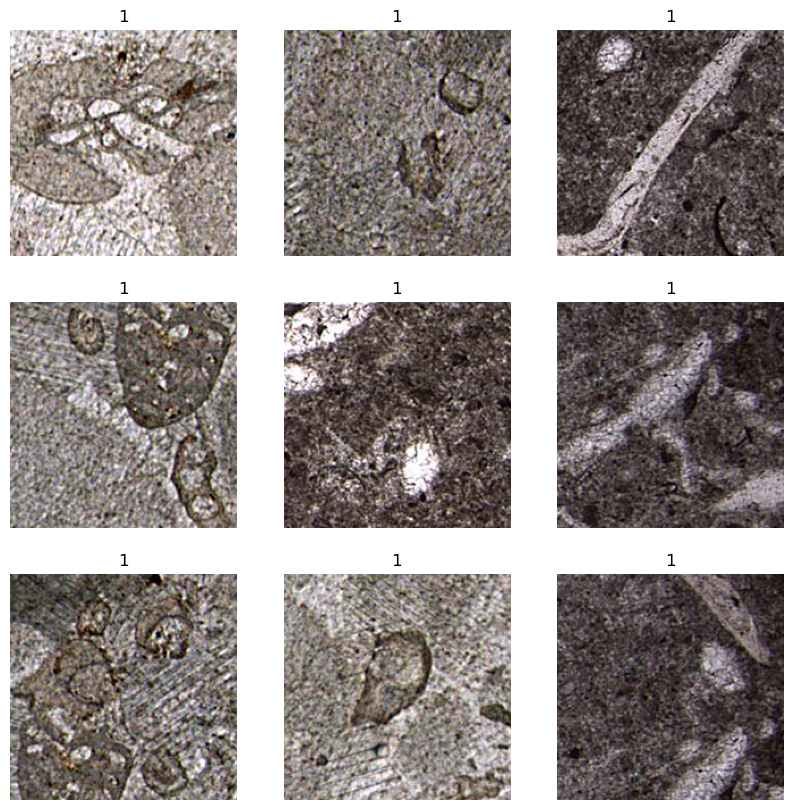

In [16]:
# First, upload and format carbonate world data as testing data
Unseen_Fossil_Data_Filepath = "/Users/lucyhelms/MLGeo2026/test_fossil"
Unseen_NonFossil_Data_Filepath = "/Users/lucyhelms/MLGeo2026/test_no_fossil"

Unseen_Fossil_Data_Names = []
# Read images 
for filename in os.listdir(Unseen_Fossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_Fossil_Data_Filepath, filename)
        Unseen_Fossil_Data_Names.append(filepath)
unseen_test_fossil_data = [io.imread(im) for im in Unseen_Fossil_Data_Names]
unseen_test_fossil_data = np.stack(unseen_test_fossil_data)

Unseen_NonFossil_Data_Names = []
for filename in os.listdir(Unseen_NonFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_NonFossil_Data_Filepath, filename)
        Unseen_NonFossil_Data_Names.append(filepath)
unseen_test_nonfossil_data = [io.imread(im) for im in Unseen_NonFossil_Data_Names]
unseen_test_nonfossil_data = np.stack(unseen_test_nonfossil_data)

unseen_test_vals = np.concatenate([np.ones(unseen_test_fossil_data.shape[0]), np.zeros(unseen_test_nonfossil_data.shape[0])])
unseen_test_data = np.concatenate([unseen_test_fossil_data, unseen_test_nonfossil_data])

# Put into correct format
unseen_test_data = tf.data.Dataset.from_tensor_slices((unseen_test_data, unseen_test_vals))

# Verify via plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(unseen_test_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")

# Batch
unseen_test_data = unseen_test_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()


In [17]:
print("Unseen Test Data Evaluation:")
unseen_test_eval = model.evaluate(unseen_test_data)

Unseen Test Data Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 754ms/step - auc_1: 0.7229 - binary_accuracy: 0.6122 - loss: 0.6742 - precision_1: 0.9000 - recall_1: 0.6279


Plotting Accuracy and Loss

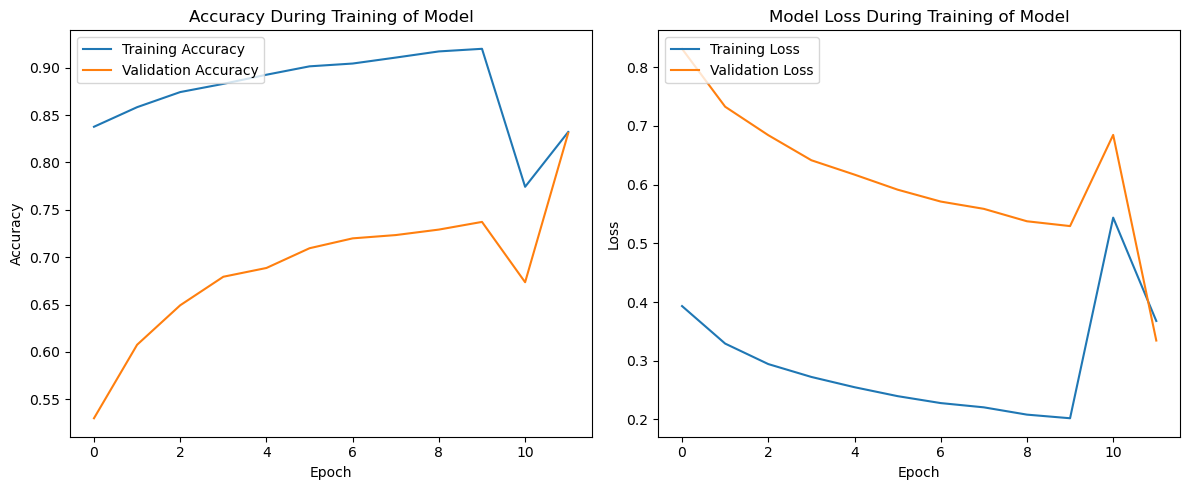

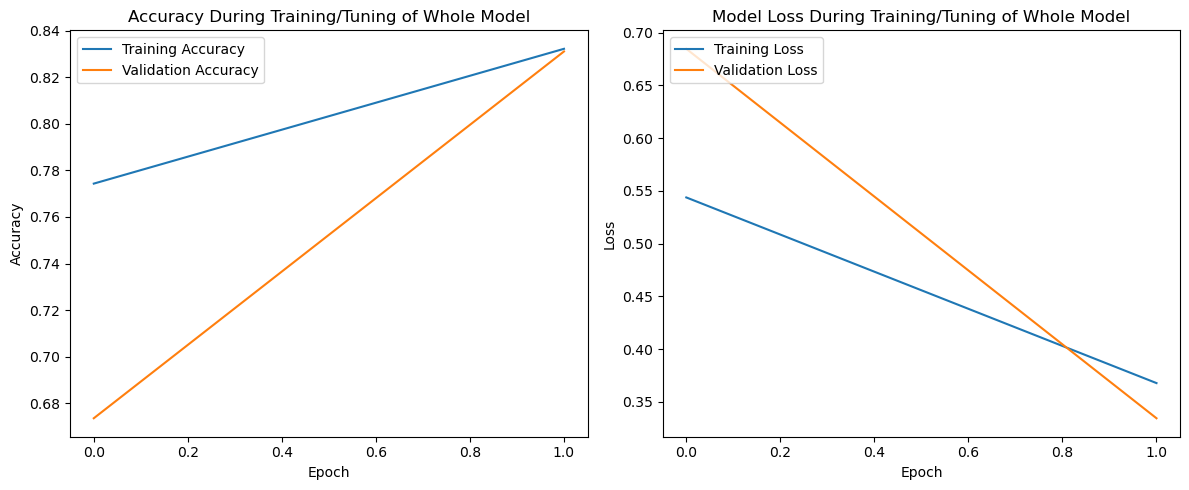

In [18]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.concatenate([history_our_layers.history['binary_accuracy'], history_whole_model.history['binary_accuracy']]), label='Training Accuracy')
plt.plot(np.concatenate([history_our_layers.history['val_binary_accuracy'],history_whole_model.history['val_binary_accuracy']]), label='Validation Accuracy')
plt.title('Accuracy During Training of Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(np.concatenate([history_our_layers.history['loss'], history_whole_model.history['loss']]), label='Training Loss')
plt.plot(np.concatenate([history_our_layers.history['val_loss'], history_whole_model.history['val_loss']]), label='Validation Loss')
plt.title('Model Loss During Training of Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_whole_model.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history_whole_model.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Accuracy During Training/Tuning of Whole Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_whole_model.history['loss'], label='Training Loss')
plt.plot(history_whole_model.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training/Tuning of Whole Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [19]:
preds = model.predict(unseen_test_data)
predictions = np.zeros(preds.shape)
for i in range(len(preds)):
    if preds[i] >= 0.5:
        predictions[i] = 1
    else:
        predictions[i] = 0
print(predictions)
print(unseen_test_vals)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
[[1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.
 0.]


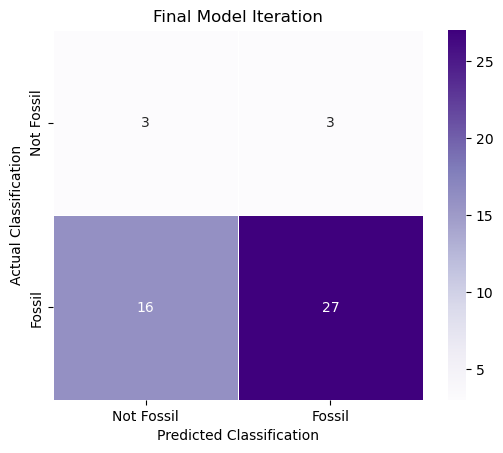

In [22]:
# confusion matrix plot

cm = confusion_matrix(unseen_test_vals, predictions)


# plotting as a heat map
sns.heatmap(
    cm,
    annot=True,         # Annotate the cells with the numeric value
    cmap='Purples',       # Color map (e.g., 'Blues', 'Viridis')
    fmt='d',            # Format annotations as integers
    linewidths=.5,      # Add lines between cells
    square=True,        # Force cells to be square
    cbar=True,          # Display a color bar
    xticklabels=["Not Fossil", "Fossil"],
    yticklabels=["Not Fossil", "Fossil"]
)
# Add labels and title
plt.ylabel("Actual Classification")
plt.xlabel("Predicted Classification")
plt.title("Final Model Iteration")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step


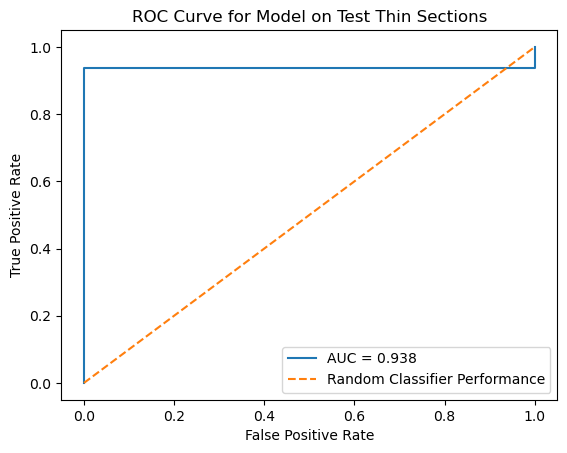

<Figure size 640x480 with 0 Axes>

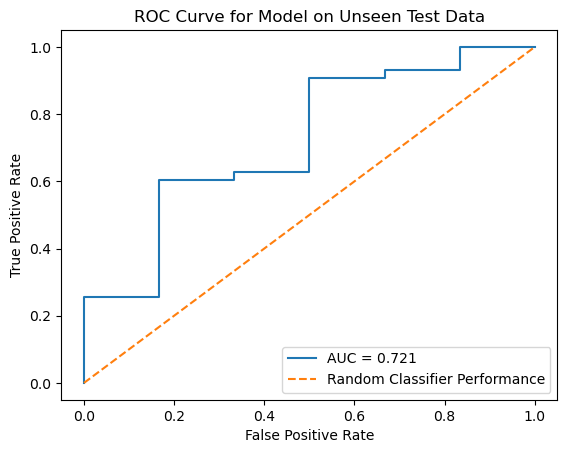

In [21]:
# ROC Curve Plot
predictions_test = model.predict(testing_data)
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(Y_test, predictions_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle = "--", label = "Random Classifier Performance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Model on Test Thin Sections")
plt.legend()
plt.show()

plt.figure()
fpr, tpr, thresholds = roc_curve(unseen_test_vals, preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle = "--", label = "Random Classifier Performance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Model on Unseen Test Data")
plt.legend()
plt.show()
